# 1.2 Reddit: Network Analysis

This notebook analyses the structural relationships between Reddit subreddits and candidate-buzz clusters using the **silver-layer** cleaned data.

Three complementary network perspectives:
1. **Subreddit overlap network** — subreddits as nodes, Jaccard author-overlap as edges
2. **Keyword similarity network** — subreddits connected by TF-IDF cosine similarity of their vocabulary
3. **Candidate-buzz flow** — cross-cluster echo-chamber analysis (TrumpBuzz / HarrisBuzz / ElectionBuzz)

**Input:** `Data/2_Silver/Reddit/reddit_posts_clean.parquet` · `reddit_comments_clean.parquet`


<!-- toc -->
## Contents
- **[1. Setup](#1-setup)**
- **[2. Load Data](#2-load-data)**
- **[3. Subreddit Overlap Network](#3-subreddit-overlap-network)**
- **[4. Cross-subreddit Author Activity](#4-cross-subreddit-author-activity)**
- **[5. Keyword Similarity Network](#5-keyword-similarity-network)**
- **[6. Candidate Buzz Flow](#6-candidate-buzz-flow)**
- **[7. Summary](#7-summary)**


## 1. Setup


In [1]:
import sys
sys.path.insert(0, '../..')
from house_style import (
    apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, REPUBLICAN, DEMOCRAT, NEUTRAL,
    TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR, PALETTE,
    BUZZ_COLORS,
)
apply_style()

from pathlib import Path
from collections import Counter
import ast

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DATA_DIR = Path('../../Data/2_Silver/Reddit')

# Political leaning per subreddit (manual assignment)
LEANING = {
    'conservative': 'right',
    'trump':        'right',
    'republican':   'right',
    'politics':     'center',
    'worldnews':    'center',
    'democrats':    'left',
    'liberal':      'left',
}

# Colour per political leaning
LEANING_COLORS = {
    'left':   DEMOCRAT,
    'right':  REPUBLICAN,
    'center': NEUTRAL,
}

# Colour per subreddit
SUBREDDIT_COLORS = {
    'conservative': REPUBLICAN,
    'trump':        '#c0392b',
    'republican':   '#e07b39',
    'politics':     '#f39c12',
    'worldnews':    '#2ecc71',
    'democrats':    DEMOCRAT,
    'liberal':      '#5dade2',
}


## 2. Load Data


In [2]:
# Load silver posts and comments
posts    = pd.read_parquet(DATA_DIR / 'reddit_posts_clean.parquet')
comments = pd.read_parquet(DATA_DIR / 'reddit_comments_clean.parquet')

# Remove deleted / bot accounts
BOTS = {'[deleted]', 'AutoModerator', 'BotDefense', 'RemindMeBot'}
posts    = posts[~posts['author'].isin(BOTS)]
comments = comments[~comments['author'].isin(BOTS)]

print(f'Posts    : {len(posts):>9,}  |  subreddits: {posts["subreddit"].nunique()}')
print(f'Comments : {len(comments):>9,}  |  subreddits: {comments["subreddit"].nunique()}')
print()
print('Posts per subreddit:')
print(posts['subreddit'].value_counts().to_string())
print()
print('Candidate distribution (posts):')
print(posts['candidate'].value_counts().to_string())


Posts    :   103,008  |  subreddits: 7
Comments : 1,321,876  |  subreddits: 7

Posts per subreddit:
subreddit
politics        49160
conservative    20761
democrats       13203
trump            9340
republican       5378
worldnews        4112
liberal          1054

Candidate distribution (posts):
candidate
TrumpBuzz       42146
HarrisBuzz      36297
ElectionBuzz    24565


## 3. Subreddit Overlap Network


Subreddits are modelled as **nodes**. Two subreddits are connected if their author sets overlap.  
Edge weight = **Jaccard similarity**: |A ∩ B| / |A ∪ B|, so values range from 0 (no shared authors) to 1 (identical author sets).  
This gives a *unipartite* subreddit–subreddit graph built from the underlying bipartite author–subreddit graph.


In [3]:
# Combine posts + comments to get full author-subreddit co-occurrence
author_sub = pd.concat([
    posts[['author', 'subreddit']],
    comments[['author', 'subreddit']],
]).drop_duplicates()

# Build author sets per subreddit
subs = sorted(author_sub['subreddit'].unique())
sub_authors = {s: set(author_sub[author_sub['subreddit'] == s]['author']) for s in subs}

# Jaccard matrix
n = len(subs)
J = np.zeros((n, n))
for i, s1 in enumerate(subs):
    for j, s2 in enumerate(subs):
        inter = len(sub_authors[s1] & sub_authors[s2])
        union = len(sub_authors[s1] | sub_authors[s2])
        J[i, j] = inter / union if union > 0 else 0

J_df = pd.DataFrame(J, index=subs, columns=subs)

print('Jaccard similarity matrix (author overlap):')
print(J_df.round(3).to_string())


Jaccard similarity matrix (author overlap):
              conservative  democrats  liberal  politics  republican  trump  worldnews
conservative         1.000      0.019    0.005     0.034       0.051  0.039      0.020
democrats            0.019      1.000    0.032     0.058       0.016  0.009      0.032
liberal              0.005      0.032    1.000     0.005       0.006  0.003      0.003
politics             0.034      0.058    0.005     1.000       0.006  0.006      0.078
republican           0.051      0.016    0.006     0.006       1.000  0.051      0.003
trump                0.039      0.009    0.003     0.006       0.051  1.000      0.004
worldnews            0.020      0.032    0.003     0.078       0.003  0.004      1.000


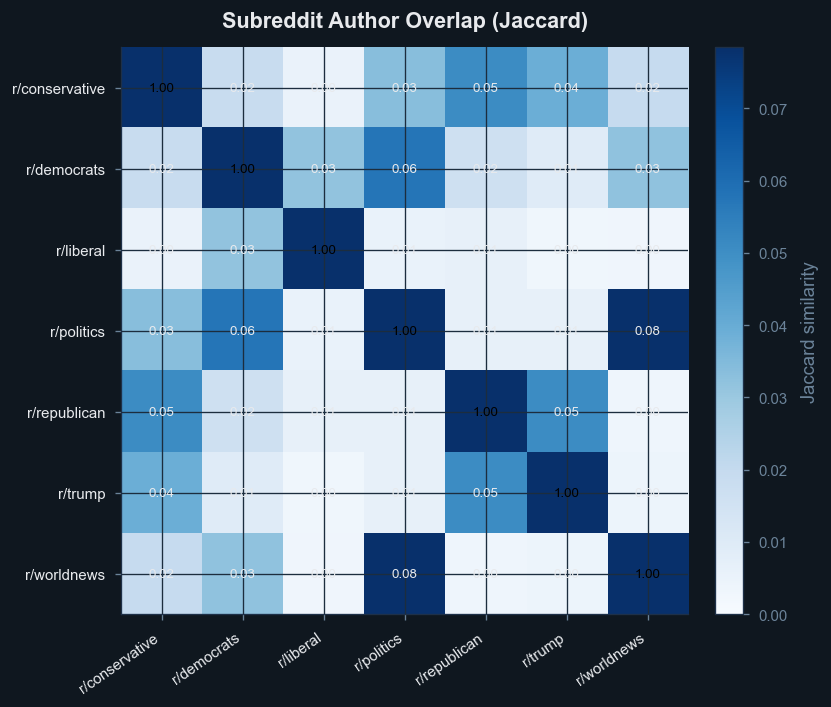

In [4]:
# --- Heatmap ---
fig, ax = styled_fig(figsize=(7, 6))

im = ax.imshow(J, cmap='Blues', vmin=0, vmax=J[J < 1].max())

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f'r/{s}' for s in subs], rotation=35, ha='right', color=TEXT_PRIMARY, fontsize=9)
ax.set_yticklabels([f'r/{s}' for s in subs], color=TEXT_PRIMARY, fontsize=9)

for i in range(n):
    for j in range(n):
        val = J[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='black' if val > 0.12 else TEXT_PRIMARY)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Jaccard similarity', color=TEXT_MUTED)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)

ax.set_title('Subreddit Author Overlap (Jaccard)', color=TEXT_PRIMARY, fontsize=13)
plt.tight_layout()
plt.show()


C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_21492\3114505682.py:50: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\verme_hzys4y0\miniconda3\envs\SWMA2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


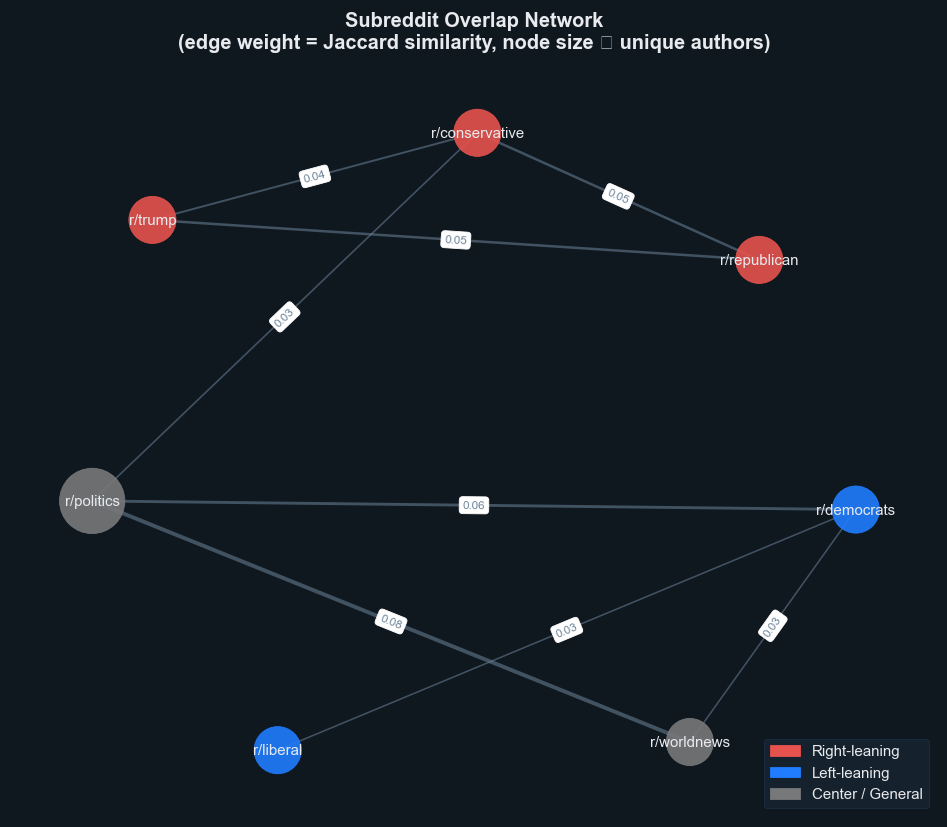

In [5]:
# --- Network graph ---
# Only keep edges above a minimum threshold to avoid clutter
MIN_JACCARD = 0.02

G_overlap = nx.Graph()
for s in subs:
    G_overlap.add_node(s, leaning=LEANING.get(s, 'center'))

for i, s1 in enumerate(subs):
    for j, s2 in enumerate(subs):
        if i < j and J[i, j] >= MIN_JACCARD:
            G_overlap.add_edge(s1, s2, weight=J[i, j])

# Layout & drawing
pos = nx.spring_layout(G_overlap, seed=42, weight='weight', k=2.5)

node_colors = [LEANING_COLORS.get(LEANING.get(s, 'center'), NEUTRAL) for s in G_overlap.nodes()]
node_sizes  = [max(800, sub_authors[s].__len__() // 100) for s in G_overlap.nodes()]
edge_weights= [G_overlap[u][v]['weight'] for u, v in G_overlap.edges()]
edge_widths = [w * 30 for w in edge_weights]

fig, ax = styled_fig(figsize=(8, 7))
ax.axis('off')

nx.draw_networkx_edges(G_overlap, pos, ax=ax,
                       width=edge_widths, alpha=0.55,
                       edge_color=TEXT_MUTED)
nx.draw_networkx_nodes(G_overlap, pos, ax=ax,
                       node_color=node_colors,
                       node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_overlap, pos, ax=ax,
                        labels={s: f'r/{s}' for s in G_overlap.nodes()},
                        font_color=TEXT_PRIMARY, font_size=9)

# Edge-weight annotations
edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G_overlap.edges(data=True)}
nx.draw_networkx_edge_labels(G_overlap, pos, edge_labels=edge_labels,
                             font_color=TEXT_MUTED, font_size=7, ax=ax)

legend_handles = [
    mpatches.Patch(color=REPUBLICAN, label='Right-leaning'),
    mpatches.Patch(color=DEMOCRAT,   label='Left-leaning'),
    mpatches.Patch(color=NEUTRAL,    label='Center / General'),
]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

ax.set_title('Subreddit Overlap Network\n(edge weight = Jaccard similarity, node size ∝ unique authors)',
             color=TEXT_PRIMARY, fontsize=12)
plt.tight_layout()
plt.show()


**Insight — Overlap network:**  
r/politics and r/worldnews act as bridge nodes: they share a meaningful fraction of their author base with all other subreddits.  
Ideologically opposed communities (conservative vs. democrats, liberal vs. trump) show near-zero Jaccard overlap, indicating strong audience separation.  
Smaller right-leaning subreddits (r/republican, r/trump) overlap most with r/conservative rather than with cross-partisan communities.


## 4. Cross-subreddit Author Activity


In [6]:
# How many distinct subreddits does each author post/comment in?
author_subs = (
    author_sub.groupby('author')['subreddit']
    .apply(set)
    .reset_index()
)
author_subs.columns = ['author', 'subreddits']
author_subs['n_subs'] = author_subs['subreddits'].apply(len)

# Political leaning of subreddits per author
def classify_author(sub_set):
    leanings = {LEANING.get(s, 'center') for s in sub_set}
    if 'left' in leanings and 'right' in leanings:
        return 'Cross-partisan'
    if 'left' in leanings:
        return 'Left only'
    if 'right' in leanings:
        return 'Right only'
    return 'Center only'

author_subs['profile'] = author_subs['subreddits'].apply(classify_author)

print('Authors by number of active subreddits:')
print(author_subs['n_subs'].value_counts().sort_index().to_string())
print()
print('Authors by political profile:')
print(author_subs['profile'].value_counts().to_string())


Authors by number of active subreddits:
n_subs
1    210982
2     30589
3      4007
4       436
5        55
6        15

Authors by political profile:
profile
Center only       174964
Right only         36825
Left only          32378
Cross-partisan      1917


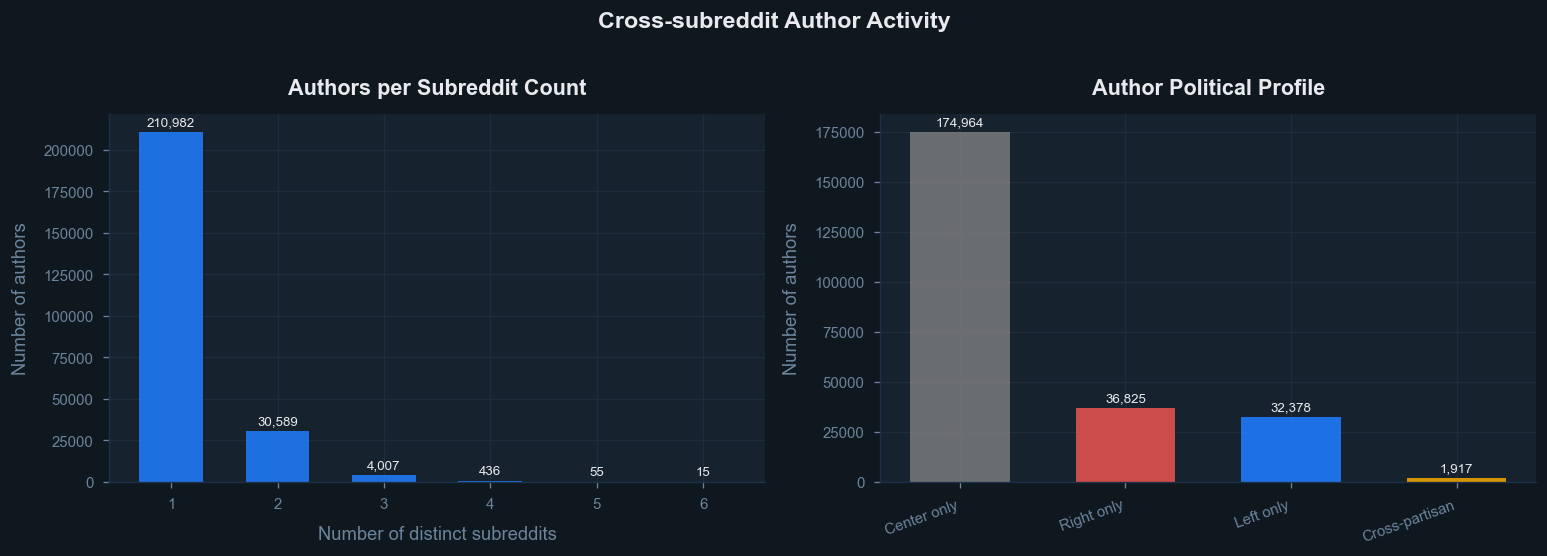

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG_DARK)

# Left: distribution of subreddit count per author
ax0 = axes[0]
ax0.set_facecolor(BG_PANEL)
counts = author_subs['n_subs'].value_counts().sort_index()
bars = ax0.bar(counts.index, counts.values, color=DEMOCRAT, alpha=0.85, width=0.6)
for bar in bars:
    h = bar.get_height()
    ax0.text(bar.get_x() + bar.get_width() / 2, h + counts.max() * 0.01,
             f'{h:,}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=8)
ax0.set_xlabel('Number of distinct subreddits', color=TEXT_MUTED)
ax0.set_ylabel('Number of authors', color=TEXT_MUTED)
ax0.set_title('Authors per Subreddit Count', color=TEXT_PRIMARY)
ax0.tick_params(colors=TEXT_MUTED)
ax0.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
ax0.set_axisbelow(True)

# Right: political profile breakdown
ax1 = axes[1]
ax1.set_facecolor(BG_PANEL)
profile_colors = {
    'Left only':      DEMOCRAT,
    'Right only':     REPUBLICAN,
    'Center only':    NEUTRAL,
    'Cross-partisan': '#f0a500',
}
profile_counts = author_subs['profile'].value_counts()
bars2 = ax1.bar(
    range(len(profile_counts)),
    profile_counts.values,
    color=[profile_colors.get(p, NEUTRAL) for p in profile_counts.index],
    alpha=0.88, width=0.6
)
for bar in bars2:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, h + profile_counts.max() * 0.01,
             f'{h:,}', ha='center', va='bottom', color=TEXT_PRIMARY, fontsize=8)
ax1.set_xticks(range(len(profile_counts)))
ax1.set_xticklabels(profile_counts.index, rotation=20, ha='right', color=TEXT_PRIMARY, fontsize=9)
ax1.set_ylabel('Number of authors', color=TEXT_MUTED)
ax1.set_title('Author Political Profile', color=TEXT_PRIMARY)
ax1.tick_params(colors=TEXT_MUTED)
ax1.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
ax1.set_axisbelow(True)

plt.suptitle('Cross-subreddit Author Activity', color=TEXT_PRIMARY, fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Insight — Cross-subreddit activity:**  
The vast majority of authors post exclusively in one subreddit. Cross-partisan authors (active in both left- and right-leaning subreddits) are a small minority, suggesting highly segregated audience communities.  
Authors in center subreddits (r/politics, r/worldnews) are more likely to also appear elsewhere.


## 5. Keyword Similarity Network


Each subreddit is represented as a **TF-IDF vector** over its entire vocabulary (post titles + text).  
Edges are drawn where **cosine similarity ≥ threshold** (85th percentile of all pairwise similarities).  
This reveals which communities discuss the same topics, independently of shared authors.


In [12]:
# Build per-subreddit text corpus from posts
# 'words' column is a numpy array of tokens — join directly
def safe_parse_words(w):
    """Handles: numpy/list arrays, string repr of lists, plain strings."""
    try:
        if hasattr(w, '__iter__') and not isinstance(w, str):
            return ' '.join(str(t) for t in w)
        if isinstance(w, str) and w.startswith('['):
            import ast as _ast
            return ' '.join(_ast.literal_eval(w))
        return str(w) if w else ''
    except Exception:
        return ''

posts['text_str'] = posts['words'].apply(safe_parse_words)

sub_corpus = (
    posts.groupby('subreddit')['text_str']
    .apply(lambda texts: ' '.join(texts))
    .reset_index()
)
sub_corpus.columns = ['subreddit', 'corpus']

# TF-IDF vectorisation
vec = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, sublinear_tf=True)
X   = vec.fit_transform(sub_corpus['corpus'])
subs_ordered = list(sub_corpus['subreddit'])

cos_sim = cosine_similarity(X)
cos_df  = pd.DataFrame(cos_sim, index=subs_ordered, columns=subs_ordered)

print('Cosine similarity matrix (TF-IDF keyword overlap):')
print(cos_df.round(3).to_string())

# Threshold: 85th percentile of off-diagonal values
offdiag = cos_sim[np.triu_indices_from(cos_sim, k=1)]
threshold = np.percentile(offdiag, 85)
print(f'Threshold (85th percentile): {threshold:.4f}')


Cosine similarity matrix (TF-IDF keyword overlap):
              conservative  democrats  liberal  politics  republican  trump  worldnews
conservative         1.000      0.891    0.484     0.911       0.813  0.860      0.499
democrats            0.891      1.000    0.541     0.914       0.762  0.847      0.445
liberal              0.484      0.541    1.000     0.464       0.435  0.515      0.073
politics             0.911      0.914    0.464     1.000       0.743  0.808      0.534
republican           0.813      0.762    0.435     0.743       1.000  0.808      0.388
trump                0.860      0.847    0.515     0.808       0.808  1.000      0.420
worldnews            0.499      0.445    0.073     0.534       0.388  0.420      1.000
Threshold (85th percentile): 0.8603


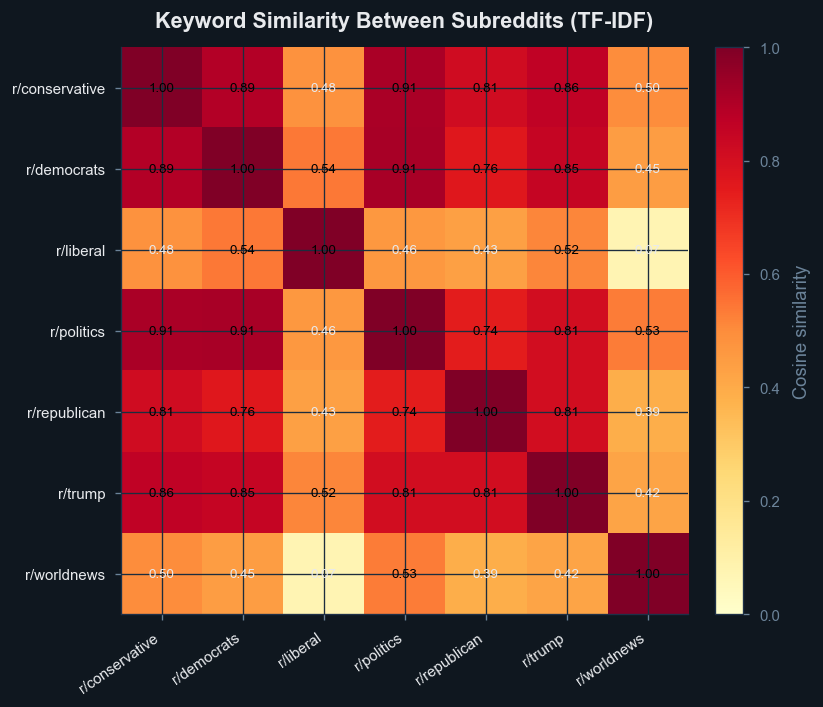

In [13]:
fig, ax = styled_fig(figsize=(7, 6))

im = ax.imshow(cos_sim, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(subs_ordered)))
ax.set_yticks(range(len(subs_ordered)))
ax.set_xticklabels([f'r/{s}' for s in subs_ordered], rotation=35, ha='right',
                   color=TEXT_PRIMARY, fontsize=9)
ax.set_yticklabels([f'r/{s}' for s in subs_ordered], color=TEXT_PRIMARY, fontsize=9)

for i in range(len(subs_ordered)):
    for j in range(len(subs_ordered)):
        val = cos_sim[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='black' if val > 0.5 else TEXT_PRIMARY)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Cosine similarity', color=TEXT_MUTED)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)

ax.set_title('Keyword Similarity Between Subreddits (TF-IDF)', color=TEXT_PRIMARY, fontsize=13)
plt.tight_layout()
plt.show()


C:\Users\verme_hzys4y0\AppData\Local\Temp\ipykernel_21492\160929139.py:46: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\verme_hzys4y0\miniconda3\envs\SWMA2026\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


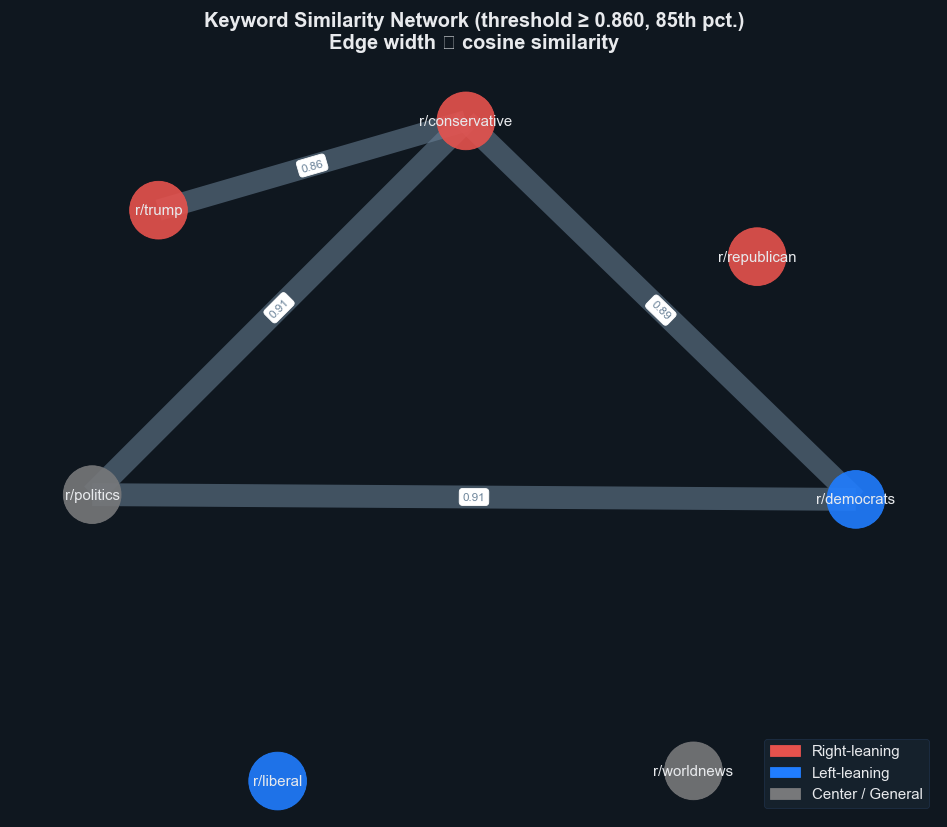

In [14]:
# Build graph with threshold edges
G_kw = nx.Graph()
for s in subs_ordered:
    G_kw.add_node(s, leaning=LEANING.get(s, 'center'))

for i, s1 in enumerate(subs_ordered):
    for j, s2 in enumerate(subs_ordered):
        if i < j and cos_sim[i, j] >= threshold:
            G_kw.add_edge(s1, s2, weight=cos_sim[i, j])

pos_kw = nx.spring_layout(G_kw, seed=42, weight='weight', k=3.0)

node_colors_kw = [LEANING_COLORS.get(LEANING.get(s, 'center'), NEUTRAL) for s in G_kw.nodes()]
edge_weights_kw = [G_kw[u][v]['weight'] for u, v in G_kw.edges()]
edge_widths_kw  = [w * 15 for w in edge_weights_kw]

fig, ax = styled_fig(figsize=(8, 7))
ax.axis('off')

nx.draw_networkx_edges(G_kw, pos_kw, ax=ax,
                       width=edge_widths_kw, alpha=0.55, edge_color=TEXT_MUTED)
nx.draw_networkx_nodes(G_kw, pos_kw, ax=ax,
                       node_color=node_colors_kw,
                       node_size=1200, alpha=0.9)
nx.draw_networkx_labels(G_kw, pos_kw, ax=ax,
                        labels={s: f'r/{s}' for s in G_kw.nodes()},
                        font_color=TEXT_PRIMARY, font_size=9)

edge_labels_kw = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G_kw.edges(data=True)}
nx.draw_networkx_edge_labels(G_kw, pos_kw, edge_labels=edge_labels_kw,
                             font_color=TEXT_MUTED, font_size=7, ax=ax)

legend_handles = [
    mpatches.Patch(color=REPUBLICAN, label='Right-leaning'),
    mpatches.Patch(color=DEMOCRAT,   label='Left-leaning'),
    mpatches.Patch(color=NEUTRAL,    label='Center / General'),
]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

ax.set_title(
    f'Keyword Similarity Network (threshold ≥ {threshold:.3f}, 85th pct.)\n'
    'Edge width ∝ cosine similarity',
    color=TEXT_PRIMARY, fontsize=12
)
plt.tight_layout()
plt.show()


In [16]:
# Network characteristics
print('=== Keyword Similarity Network — Characteristics ===')
print(f'  Nodes   : {G_kw.number_of_nodes()}')
print(f'  Edges   : {G_kw.number_of_edges()}')
print(f'  Density : {nx.density(G_kw):.4f}')
if nx.is_connected(G_kw):
    print(f'  Diameter : {nx.diameter(G_kw)}')

print()
dc = nx.degree_centrality(G_kw)
bc = nx.betweenness_centrality(G_kw, weight='weight')
pr = nx.pagerank(G_kw, weight='weight')

# Use a fixed node order so all columns align
nodes = list(G_kw.nodes())
centrality_df = pd.DataFrame({
    'degree_centrality'     : [dc[n] for n in nodes],
    'betweenness_centrality': [bc[n] for n in nodes],
    'pagerank'              : [pr[n] for n in nodes],
    'leaning'               : [LEANING.get(n, 'center') for n in nodes],
}, index=nodes).sort_values('pagerank', ascending=False)

print('Centrality rankings:')
print(centrality_df.round(4).to_string())


=== Keyword Similarity Network — Characteristics ===
  Nodes   : 7
  Edges   : 4
  Density : 0.1905

Centrality rankings:
              degree_centrality  betweenness_centrality  pagerank leaning
conservative             0.5000                  0.1333    0.3277   right
politics                 0.3333                  0.0000    0.2249  center
democrats                0.3333                  0.0000    0.2226    left
trump                    0.1667                  0.0000    0.1237   right
liberal                  0.0000                  0.0000    0.0337    left
republican               0.0000                  0.0000    0.0337   right
worldnews                0.0000                  0.0000    0.0337  center


**Insight — Keyword similarity network:**  
Subreddits cluster by political leaning in topic space as well as in author overlap.  
r/politics and r/worldnews tend to be central mediators with broad topical similarity to both sides.  
Right-leaning subreddits (conservative, trump, republican) form a tight vocabulary cluster, sharing election-related terms.  
Left-leaning subreddits (democrats, liberal) similarly cluster together, though with lower internal similarity than the right.


## 6. Candidate Buzz Flow


Posts are tagged as **TrumpBuzz**, **HarrisBuzz**, or **ElectionBuzz** based on the hashtag cluster they were collected from.  
Note: this reflects the *collection hashtag*, not the author's political stance — a TrumpBuzz post may be pro- or anti-Trump.

We analyse:
- How buzz types are distributed across subreddits
- Which authors post in multiple buzz clusters (cross-cluster bridge nodes)


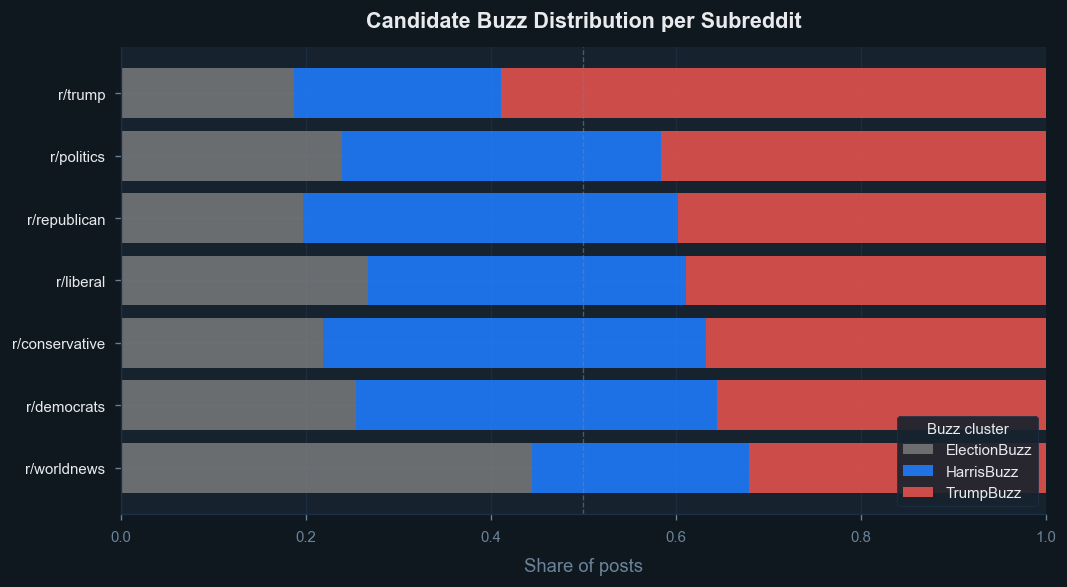

In [17]:
# Buzz distribution per subreddit (stacked bar)
buzz_sub = (
    posts.groupby(['subreddit', 'candidate'])
    .size()
    .reset_index(name='count')
)
buzz_pivot = buzz_sub.pivot(index='subreddit', columns='candidate', values='count').fillna(0)
buzz_pivot_pct = buzz_pivot.div(buzz_pivot.sum(axis=1), axis=0)

# Sort subreddits by Trump-buzz share (descending)
if 'TrumpBuzz' in buzz_pivot_pct.columns:
    buzz_pivot_pct = buzz_pivot_pct.sort_values('TrumpBuzz', ascending=True)

fig, ax = styled_fig(figsize=(9, 5))

bottom = np.zeros(len(buzz_pivot_pct))
for col in buzz_pivot_pct.columns:
    vals = buzz_pivot_pct[col].values
    bars = ax.barh(
        range(len(buzz_pivot_pct)), vals,
        left=bottom, label=col,
        color=BUZZ_COLORS.get(col, NEUTRAL), alpha=0.88
    )
    bottom += vals

ax.set_yticks(range(len(buzz_pivot_pct)))
ax.set_yticklabels([f'r/{s}' for s in buzz_pivot_pct.index], color=TEXT_PRIMARY)
ax.set_xlabel('Share of posts', color=TEXT_MUTED)
ax.set_title('Candidate Buzz Distribution per Subreddit', color=TEXT_PRIMARY, fontsize=13)
ax.set_xlim(0, 1)
ax.axvline(0.5, color=TEXT_MUTED, linewidth=0.8, linestyle='--', alpha=0.6)

ax.legend(
    title='Buzz cluster',
    loc='lower right',
    facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY,
    title_fontsize=9
)
plt.tight_layout()
plt.show()


In [18]:
# Echo-chamber: how many authors appear in multiple buzz clusters?
author_buzz = (
    posts.groupby('author')['candidate']
    .apply(set)
    .reset_index()
)
author_buzz.columns = ['author', 'buzz_set']
author_buzz['n_clusters'] = author_buzz['buzz_set'].apply(len)

print('Authors by number of distinct buzz clusters:')
print(author_buzz['n_clusters'].value_counts().sort_index().to_string())

# Cross-cluster overlap matrix
buzz_types = ['TrumpBuzz', 'HarrisBuzz', 'ElectionBuzz']
buzz_authors = {b: set(posts[posts['candidate'] == b]['author']) for b in buzz_types}
overlap = np.zeros((3, 3))
for i, b1 in enumerate(buzz_types):
    for j, b2 in enumerate(buzz_types):
        inter = len(buzz_authors[b1] & buzz_authors[b2])
        union = len(buzz_authors[b1] | buzz_authors[b2])
        overlap[i, j] = inter / union if union > 0 else 0

overlap_df = pd.DataFrame(overlap, index=buzz_types, columns=buzz_types)
print('\nCross-cluster Jaccard overlap matrix:')
print(overlap_df.round(3).to_string())


Authors by number of distinct buzz clusters:
n_clusters
1    25542
2     4087
3     2179

Cross-cluster Jaccard overlap matrix:
              TrumpBuzz  HarrisBuzz  ElectionBuzz
TrumpBuzz         1.000       0.145         0.150
HarrisBuzz        0.145       1.000         0.164
ElectionBuzz      0.150       0.164         1.000


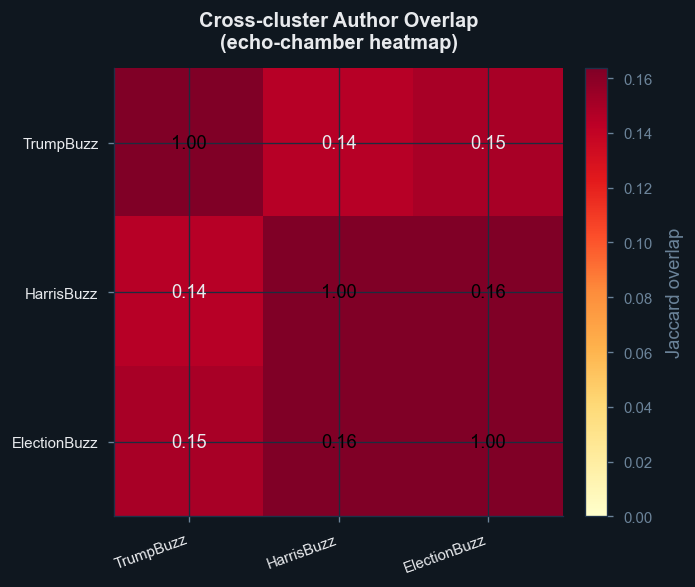

In [19]:
fig, ax = styled_fig(figsize=(6, 5))

im = ax.imshow(overlap, cmap='YlOrRd', vmin=0, vmax=overlap[overlap < 1].max())
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(buzz_types, rotation=20, ha='right', color=TEXT_PRIMARY)
ax.set_yticklabels(buzz_types, color=TEXT_PRIMARY)

for i in range(3):
    for j in range(3):
        val = overlap[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=11,
                color='black' if val > 0.15 else TEXT_PRIMARY)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Jaccard overlap', color=TEXT_MUTED)
cbar.ax.yaxis.set_tick_params(color=TEXT_MUTED)

ax.set_title('Cross-cluster Author Overlap\n(echo-chamber heatmap)', color=TEXT_PRIMARY, fontsize=12)
plt.tight_layout()
plt.show()


**Insight — Candidate buzz flow:**  
TrumpBuzz and HarrisBuzz share very few authors, confirming that users predominantly engage with one candidate's content.  
ElectionBuzz overlaps more with both TrumpBuzz and HarrisBuzz — as expected from its general election framing.  
The low cross-cluster Jaccard values are consistent with echo-chamber behaviour: Reddit users mostly stay within their ideologically aligned content streams.


## 7. Summary


In [20]:
print('=' * 55)
print('  REDDIT NETWORK ANALYSIS — SUMMARY')
print('=' * 55)
print()
print(f'  Total posts         : {len(posts):>9,}')
print(f'  Total comments      : {len(comments):>9,}')
print(f'  Unique authors      : {author_subs["author"].nunique():>9,}')
print(f'  Subreddits          : {len(subs):>9}')
print()
print('  Cross-subreddit authors')
print(f'    Active in 1 sub   : {(author_subs["n_subs"] == 1).sum():>9,}')
print(f'    Active in 2+ subs : {(author_subs["n_subs"]  > 1).sum():>9,}')
cross_pct = (author_subs['n_subs'] > 1).mean() * 100
print(f'    Cross-sub rate    : {cross_pct:>8.1f}%')
print()
cp_authors = (author_subs['profile'] == 'Cross-partisan').sum()
cp_pct = cp_authors / len(author_subs) * 100
print(f'  Cross-partisan      : {cp_authors:>9,}  ({cp_pct:.1f}%)')
print()
print('  Keyword network (TF-IDF cosine similarity)')
print(f'    Nodes             : {G_kw.number_of_nodes():>9}')
print(f'    Edges             : {G_kw.number_of_edges():>9}')
print(f'    Density           : {nx.density(G_kw):>9.4f}')
print()
print('  Most central subreddit (PageRank):')
top_pr = max(pr, key=pr.get)
print(f'    r/{top_pr}  ({pr[top_pr]:.4f})')
print()
print('  Echo chamber — cross-cluster Jaccard (Trump vs Harris):')
trump_harris_j = overlap[buzz_types.index('TrumpBuzz'), buzz_types.index('HarrisBuzz')]
print(f'    {trump_harris_j:.4f}  (close to 0 = strong echo chambers)')
print('=' * 55)


  REDDIT NETWORK ANALYSIS — SUMMARY

  Total posts         :   103,008
  Total comments      : 1,321,876
  Unique authors      :   246,084
  Subreddits          :         7

  Cross-subreddit authors
    Active in 1 sub   :   210,982
    Active in 2+ subs :    35,102
    Cross-sub rate    :     14.3%

  Cross-partisan      :     1,917  (0.8%)

  Keyword network (TF-IDF cosine similarity)
    Nodes             :         7
    Edges             :         4
    Density           :    0.1905

  Most central subreddit (PageRank):
    r/conservative  (0.3277)

  Echo chamber — cross-cluster Jaccard (Trump vs Harris):
    0.1450  (close to 0 = strong echo chambers)


## Overall Conclusions

| Finding | Evidence |
|---|---|
| **Strong audience segregation** | Near-zero Jaccard overlap between ideologically opposed subreddits |
| **Bridge communities** | r/politics and r/worldnews are the main connectors between left and right communities |
| **Topical echo chambers** | Keyword similarity clusters align with political leaning, not just author co-membership |
| **Buzz cluster insularity** | Very low TrumpBuzz–HarrisBuzz author overlap confirms partisan content consumption |
| **Mostly single-subreddit users** | Majority of authors are active in only one subreddit |
